# Исследовательский анализ рынка общественного питания Москвы.

- Автор: Ядрышникова Ксения Сергеевна
- Дата:

### Цели и задачи проекта

<font color='#777778'> **Цель:** Провести исследовательский анализ данных рынка общественног питания Москвы, помочь инвесторам из фонда Shut Up and Take My Money выбрать наиболее подходящее место для стартапа.
    
**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных 
4. Сформулировать выводы по проведённому анализу. </font>

### Описание данных

<font color='#777778'>
Датасеты с заведениями общественного питания Москвы составлены на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках.
   
- `/datasets/rest_info.csv` — содержит информацию о заведениях общественного питания.
    
- `/datasets/rest_price.csv` — содержит информацию о среднем чеке в заведениях общественного питания.
    
### Описание датасета `rest_info`:
    
-  `id`  — уникальный идентификатор заведения.  

- `name` — название заведения;
    
- `address` — адрес заведения;
    
- `district` — административный район, в котором находится заведение;
    
- `category` — категория заведения;

- `hours` — информация о днях и часах работы;
    
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
    
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым:
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым.
    
- `seats` — количество посадочных мест.

    
### Описание датасета `rest_price`:

-  `id`  — уникальный идентификатор заведения.      

- `price` — категория цен в заведении;
    
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона;
    
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»;
    
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»;
</font>

### Содержимое проекта

<font color='#777778'> 
    
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

</font>

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik

In [2]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Начнем изучение данных датасета datasets/rest_info.csv — выведем первые строки методом head(), а информацию о датафрейме методом info():

In [3]:
# Выводим первые строки датафрейма на экран:
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме:
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет datasets/rest_info.csv содержит 9 столбцов и 8406 строк, в которых представлена информация о о заведениях общественного питания г.Москвы на лето 2022 года.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов корректны.
- По типам данных лучше произвести коррекцию: 
    - столбцу 'category' лучше подойдет соименный тип данных - category.
    - столбцу 'chain' явно подходит тип данных bool т.к. значения в нем выражены 0 или 1.
    - столбцу 'seats' подойдет целочисленный тип данных integer.
- Пропуски имеются в столбцах 'hours', 'seats'.
- Значения в столбцах соответствуют описанию.

Аналогично проведем знакомство с данными датасета datasets/rest_price.csv:

In [5]:
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет datasets/rest_price.csv содержит 5 столбцов, 4058 строк, содержащих информацию о среднем чеке в заведениях общественного питания г.Москвы на лето 2022 года.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов корректны.
- По типам данных лучше произвести коррекцию:
    - столбцу 'price' подойдет тип данных category, т.к. информация внем носит категориальный характер.
- Пропуски существуют во всех стобцах кроме 'id'.
- Значения в столбцах соответствуют описанию.
- лучше остаивть только числовые значения в столбце 'avg_bill'

---

### Промежуточный вывод

В результате первичного знакомства с данными датасетов можно понять следующее:
- данные выглядят достаточно корректными и полными в обоих датасетах.
- требуются изменения типов данных в датасете datasets/rest_info.csv
- следует оставить только числовые значения в столбце 'avg_bill'
- присутствует много пропусков в датасете datasets/rest_price.csv, что требует дальнейшего анализа.


### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [7]:
# Соединяем данные в единый датафрейм df:
df = info_df.merge(price_df, how = 'left', on='id')

In [8]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных

### Оптимизируем типы данных

Стобцы, требующие изменения типа данных: 

- 'category', 'price' - category,
- 'chain'- bool,
- 'seats' - integer 

In [9]:
df = df.astype({'category':'category','price':'category', 'chain':'bool'})

In [10]:
df['seats'] = pd.to_numeric(df['seats'],
                                    downcast='integer')


In [11]:
#Проверим типы данных в датафремйе:
df.dtypes

id                     object
name                   object
category             category
address                object
district               object
hours                  object
rating                float64
chain                    bool
seats                 float64
price                category
avg_bill               object
middle_avg_bill       float64
middle_coffee_cup     float64
dtype: object

In [12]:
#Проверяем результат:
df.head(50)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,False,NaN,средние,NaN,NaN,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,False,45.0,средние,Средний счёт:199 ₽,199.0,NaN
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,False,45.0,средние,Средний счёт:200–300 ₽,250.0,NaN
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,False,79.0,средние,Средний счёт:от 500 ₽,500.0,NaN
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,False,65.0,средние,Средний счёт:1000–1200 ₽,1100.0,NaN


- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейма, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [13]:
#Посчитаем абсолютное число пропусков в датафрейме, отсортируем значения:
result = df.isna().sum().reset_index(name='missing_values')
result.sort_values(by='missing_values', ascending=False)


,index,missing_values
12,middle_coffee_cup,7871
11,middle_avg_bill,5257
9,price,5091
10,avg_bill,4590
8,seats,3611
5,hours,536
0,id,0
1,name,0
2,category,0
3,address,0


In [14]:
#Посчитаем относительное число пропусков в датафрейме:
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

При знакомстве с данными мы выяснили в каких столбцах есть пропуски:

- 'middle_coffee_cup' - 7871 пропуска (93.6 %)
- 'middle_avg_bill' - 5257 пропусков   (62.53%),
- 'price' - 591 пропуск   (60.5 %),
- 'avg_bill' - 4590 пропусков   (54.6%),
- 'seats' - 3611 пропусков  (43 %),
- 'hours' - 536 пропусков    (6.37 %).





Создадим новый столбец для подсчета строк в стобце 'avg_bill', начинающихся со слов "Средний счёт:", для того чтобы посчитать количество строк, нач-ся со слов  "Средний счёт:" и соотнести полученные данные со столбцом 'middle_avg_bill'.
Сделаем аналогичные действия для подсчета строк, нач-ся со слов «Цена чашки капучино:», для того, чтобы также соотнести данные со столбцом middle_coffee_cup.

Делаются все эти действия именно здесь, в этом блоке, так как столбец avg_bill еще не потерпел изменений (а именно далее в нем останутся только числовые значения, на случай если понадобятся расчеты с этим столбцом)

In [15]:
def search_aver(z):
    if isinstance(z, str):
        a = 0
        if 'Средний счёт:' in z:
            a = a+1
            return a
        else:
            return z
    else:
        return z
df['cnt_aver_bill'] = df['avg_bill'].apply(search_aver)

In [16]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,cnt_aver_bill
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,1
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,1
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,Цена чашки капучино:155–185 ₽
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,1


In [17]:
#Создаем еще одну аналогичную функцию и новый столбец:
def search_coffee(f):
    if isinstance(f, str):
        a = 0
        if 'Цена чашки капучино:' in f:
            a = a+1
            return a
        else:
            return f
    else:
        return f
df['cnt_coffee'] = df['avg_bill'].apply(search_coffee)

In [18]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,cnt_aver_bill,cnt_coffee
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,1,Средний счёт:1500–1600 ₽
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,1,Средний счёт:от 1000 ₽
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,Цена чашки капучино:155–185 ₽,1
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,1,Средний счёт:400–600 ₽


In [19]:
#Считаем сумму строк в новых столбцах 'cnt_aver_bill' ,'cnt_coffee':
filtered_df1 = df.loc[(df['cnt_aver_bill'] == 1)]
filtered_df2 = df.loc[df['cnt_coffee'] == 1]

sum_cnt_aver_bill = filtered_df1['cnt_aver_bill'].sum(skipna=True)
sum_cnt_coffee = filtered_df2['cnt_coffee'].sum(skipna=True)


print(sum_cnt_aver_bill)
print(sum_cnt_coffee)

3149
535


Количество строк нач-ся со слов "Средний счёт:" в столбце 'avg_bill' = 3149,

Количество строк нач-ся со слов "Цена чашки капучино:" в столбце 'avg_bill' = 535

Обнаружено:

- 'middle_coffee_cup' - 7871 пропуска (93.6 %)
- 'middle_avg_bill' - 5257 пропусков   (62.53%),
- 'price' - 591 пропуск   (60.5 %),
- 'avg_bill' - 4590 пропусков   (54.6%),
- 'seats' - 3611 пропусков  (43 %),
- 'hours' - 536 пропусков    (6.37 %).
Чем можно объяснить пропуски в каждом стобце?

Для столбца 'hours: возможно дни и часы работы заведения не указаны, потому что заведение, скорее всего, закрылось/ возможно потеря данных

Для столбца 'seats': почему может быть не указано количество посадочных мест в заведении? Возможно это кассется тех заведений, где посадочные места в принципе не предусмотрены (например ряд кофеен); нет информации о пасодочных местах; ремонт в заведении/переезд/смена локации

Для столбца 'price': алиментарное отсутсивие  данных/ категория не присвоена/
потеря данных

Для столбца 'avg_bill':  заведение их не указало, возможно цены часто меняются и их решили не указывать/потеря данных

Для столбца 'middle_avg_bill': здесь ряд пропусков обусловлен тем, что сам столбец 'middle_avg_bill' включает в себя  числа с оценкой среднего чека, которые указаны только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт». 

Количество строк начинающихся  со слов "Средний счёт:" в столбце 'avg_bill' = 3149 (оно же будет и числом ненулевх значений в столбце 'middle_avg_bill'), добавляем кол-во пропусков (5257) и получаем общее количсевто строк (8406).

Для столбца 'middle_coffee_cup': .аналгично столбцу 'middle_avg_bill'. Количество строк нач-ся со слов "Цена чашки капучино:" в столбце 'avg_bill' = 535, это будет кол-во ненулевых значений в столбце 'middle_coffee_cup', остальное пропуски (7871).

Что делать с пропусками в каждом столбце? 

- 'hours' - 536 пропусков    (6.37 %)
    - тут небольшой процент и можно оставить все как есть.
- 'seats' - 3611 пропусков  (43 %),
    - лучше оставить как есть, чтобы избежать искажения данных.
- 'price' - 591 пропуск   (60.5 %),
    - можно рассмотреть вариант замены пустых значений на средние по категории, но опять же, данные так будут искажены т.к. мы не знаем какой действительно ценовой категории заведение.
- 'avg_bill' - 4590 пропусков   (54.6%),
    - отсавим как есть, так как для дальнейшего анализа у нас есть столбец 'middle_avg_bill'.
- 'middle_avg_bill' - 5257 пропусков   (62.53%),
- 'middle_coffee_cup' - 7871 пропуска (93.6 %).
    - в последних двух столбцах менять ничего не нужно, пропуски обусловлены спецификой столбцов и включают в себя определенную часть от столбца 'avg_bill'.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   category
 3   address            8406 non-null   object  
 4   district           8406 non-null   object  
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float64 
 7   chain              8406 non-null   bool    
 8   seats              4795 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  cnt_aver_bill      3816 non-null   object  
 14  cnt_coffee         3816 non-null   object  
dtypes: bool(1), category(2), float64(4), object(8)
memory u

In [21]:
#Оставим только числовые значения в столбце 'avg_bill':
def extract_avg(text):
    if isinstance(text, str):
        if '–' in text:
            numbers = text.split(':')[1].strip()
            low, high = numbers.split('–')
            low = ''.join(filter(str.isdigit, low))
            high = ''.join(filter(str.isdigit, high))
            return (int(low) + int(high)) / 2
        elif 'от' in text:
            number = text.split('от')[1].split('₽')[0].strip()
            return int(''.join(filter(str.isdigit, number)))
        else:
            return None
    else:
        return None

df['avg_bill'] = df['avg_bill'].apply(extract_avg)



In [22]:
#Проверяем чтобы все работало:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,cnt_aver_bill,cnt_coffee
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,1550.0,1550.0,NaN,1,Средний счёт:1500–1600 ₽
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,1000.0,1000.0,NaN,1,Средний счёт:от 1000 ₽
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,170.0,NaN,170.0,Цена чашки капучино:155–185 ₽,1
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,500.0,500.0,NaN,1,Средний счёт:400–600 ₽


In [23]:
# Проверяем уникальные значения в столбцах
for column in ['id', 'name', 'category', 'address', 'district', 'rating', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].unique())

Уникальные значения в столбце id:
['0c3e3439a8c64ea5bf6ecd6ca6ae19f0' '045780ada3474c57a2112e505d74b633'
 '1070b6b59144425896c65889347fcff6' ... '62e8c64d4c89467aba608e39ef87616b'
 '06a0db5ecd4842d48cd6350aa923e297' '9d56f8f7a7f74df1a925bc0fd2de8aae']
Уникальные значения в столбце name:
['WoWфли' 'Четыре комнаты' 'Хазри' ... 'Миславнес' 'Самовар' 'Kebab Time']
Уникальные значения в столбце category:
['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']
Categories (8, object): ['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']
Уникальные значения в столбце address:
['Москва, улица Дыбенко, 7/1' 'Москва, улица Дыбенко, 36, корп. 1'
 'Москва, Клязьминская улица, 15' ...
 'Москва, улица Лобачевского, 52, корп. 1'
 'Москва, Болотниковская улица, 52, корп. 2'
 'Москва, Чонгарский бульвар, 26А, корп. 1']
Уникальные значения в столбце district:
['Северный административный округ'
 'Северо-Восточный админи

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [24]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['category', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print() 

Уникальные значения в столбце category:
['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']
Categories (8, object): ['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']

Уникальные значения в столбце price:
['высокие', 'выше среднего', 'низкие', 'средние', NaN]
Categories (4, object): ['высокие', 'выше среднего', 'низкие', 'средние']



Тут все нормально.

In [25]:
# Проверяем полные дубликаты в датафрейме:
df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по id, category и address заведений должны быть уникальными, то есть каждая строка в данных — уникальное заведение.

In [26]:
# Проверяем неявные дубликаты в датафрейме? по стобцу 'id':
df.duplicated(subset='id').sum()

0

In [27]:
df.duplicated(subset=['name', 'address']).sum()

0

Дубликатов в связке 'name' и 'address' нет.

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [28]:
def work(x):
    if isinstance(x, str):
        if 'ежедневно' and 'круглосуточно' in x:
            return True
        else:
            return False
    else:
        return x

df['is_24_7'] = df['hours'].apply(work)    

In [29]:
#Столбец is_24_7 создан, проверим:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,cnt_aver_bill,cnt_coffee,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,1550.0,1550.0,NaN,1,Средний счёт:1500–1600 ₽,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,1000.0,1000.0,NaN,1,Средний счёт:от 1000 ₽,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,170.0,NaN,170.0,Цена чашки капучино:155–185 ₽,1,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,500.0,500.0,NaN,1,Средний счёт:400–600 ₽,False


In [30]:
#Напишем функцию для замены длинных названий административных округов в столбце 'district' на более короткие:
def shorter(p):
    if p == 'Северный административный округ':
        return 'Северный а.о.'
    elif p == 'Северо-Восточный административный округ':
        return 'Северо-Восточный а.о.'
    elif p == 'Северо-Западный административный округ':
        return 'Северо-Западный а.о.'
    elif p == 'Западный административный округ':
        return 'Западный а.о.'
    elif p == 'Восточный административный округ':
        return 'Восточный а.о.'
    elif p == 'Юго-Восточный административный округ':
        return 'Юго-Восточный а.о.'
    elif p == 'Юго-Западный административный округ':
        return 'Юго-Западный а.о.'
    elif p == 'Южный административный округ':
        return 'Южный а.о.'
    elif p == 'Центральный административный округ':
        return 'Центральный а.о.'
    else:
        return p
    
df['district'] = df['district'].apply(shorter)

In [31]:
#Проверим изменения:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,cnt_aver_bill,cnt_coffee,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный а.о.,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный а.о.,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,1550.0,1550.0,NaN,1,Средний счёт:1500–1600 ₽,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный а.о.,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,1000.0,1000.0,NaN,1,Средний счёт:от 1000 ₽,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный а.о.,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,170.0,NaN,170.0,Цена чашки капучино:155–185 ₽,1,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный а.о.,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,500.0,500.0,NaN,1,Средний счёт:400–600 ₽,False


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

В результате предобработки данных были выполнены следующие действия:

- Скорректированы типы данных ряда столбцов.
- Сокращены названия административных округов для удобства в дальнейшей визуализации, чтобы не перегружать график и сделать его проще к восприятию.
- Для удобства дельнейшего анализа добавлен столбец is_24_7, также добавлены столбцы cnt_aver_bill, cnt_coffee для подсчета определенных строк в 'avg_bill'	

- Проанализированы пропуски в столбцах:
    - 'hours' - 536 пропусков    (6.37 %),
    - 'seats' - 3611 пропусков  (43 %),
     - 'price' - 591 пропуск   (60.5 %),
    - 'avg_bill' - 4590 пропусков   (54.6%),
    - 'middle_avg_bill' - 5257 пропусков   (62.53%),
    - 'middle_coffee_cup' - 7871 пропуска (93.6 %).
    
- Данные проверили на явные и неявные дубликаты — в данных их нет.

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [33]:
print('Распределение данных по значениям столбца category, абсолютн.:')
df['category'].value_counts()

Распределение данных по значениям столбца category, абсолютн.:


кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [34]:
print('Распределение данных по значениям столбца category, относительн:')
df['category'].value_counts(normalize=True)

Распределение данных по значениям столбца category, относительн:


кафе               0.282893
ресторан           0.243041
кофейня            0.168094
бар,паб            0.091006
пиццерия           0.075303
быстрое питание    0.071734
столовая           0.037473
булочная           0.030454
Name: category, dtype: float64

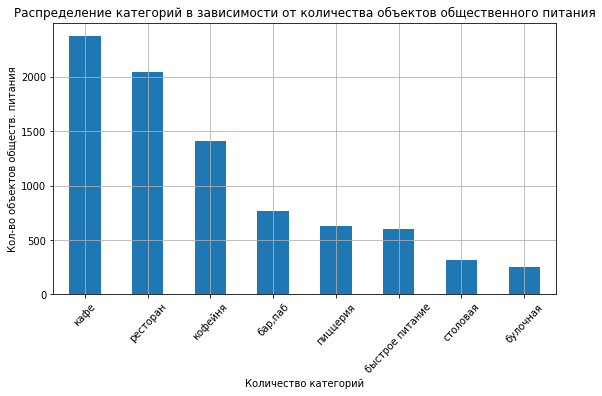

In [35]:
#Для сравнения категорий будем использовать столбчатый график.
plt.figure(figsize=(9, 5))
# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts().plot(
               kind='bar', 
               rot=47, 
               legend=False, 
               title=f'Распределение категорий в зависимости от количества объектов общественного питания'
)

# Настраиваем оформление графика
plt.xlabel('Количество категорий')
plt.ylabel('Кол-во объектов обществ. питания')

plt.grid()

plt.show()

По полулярности - лидирует категория "кафе", на втором месте "ресторан", на третьем - "кофейня".

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [37]:
print('Распределение данных по значениям столбца district:')
df['district'].value_counts()

Распределение данных по значениям столбца district:


Центральный а.о.         2242
Северный а.о.             900
Южный а.о.                892
Северо-Восточный а.о.     891
Западный а.о.             851
Восточный а.о.            798
Юго-Восточный а.о.        714
Юго-Западный а.о.         709
Северо-Западный а.о.      409
Name: district, dtype: int64

In [38]:
print('Распределение данных по значениям столбца district:')
df['district'].value_counts(normalize=True)

Распределение данных по значениям столбца district:


Центральный а.о.         0.266714
Северный а.о.            0.107066
Южный а.о.               0.106115
Северо-Восточный а.о.    0.105996
Западный а.о.            0.101237
Восточный а.о.           0.094932
Юго-Восточный а.о.       0.084939
Юго-Западный а.о.        0.084345
Северо-Западный а.о.     0.048656
Name: district, dtype: float64

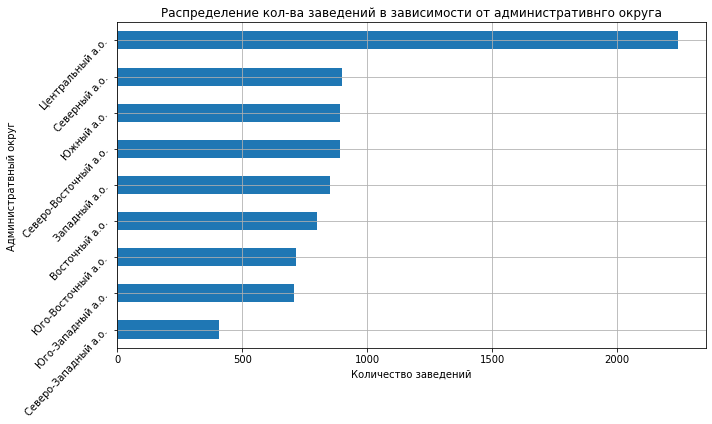

In [39]:
#Для сравнения категорий будем использовать столбчатый график.
plt.figure(figsize=(10, 6))
# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['district'].value_counts().sort_values(ascending=True).plot(
               kind='barh', 
               rot=47, 
               legend=False, 
               title=f'Распределение кол-ва заведений в зависимости от административнго округа'
)

# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('Администратвный округ')

plt.grid()
plt.tight_layout()
plt.show()

Можно заметить что Центральный административный округ лидирует с большим отрывом от остальных, меньше всего заведений - в Северо-Западном административном округе.

In [41]:
df_centr = df.loc[df['district']=='Центральный а.о.']
df_centr['category'].value_counts()


ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

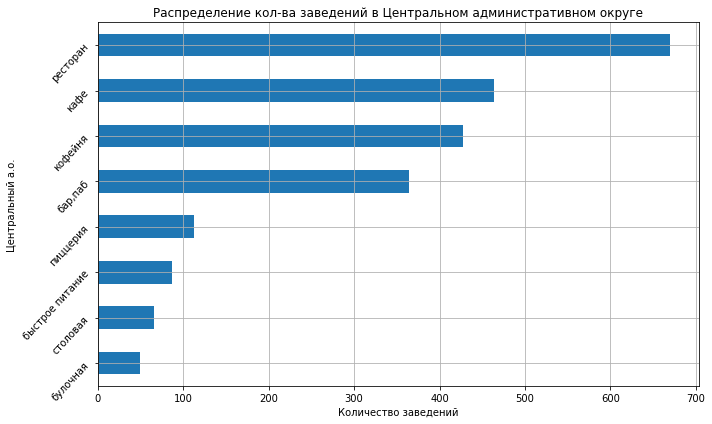

In [42]:
plt.figure(figsize=(10, 6))
# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df_centr['category'].value_counts().sort_values(ascending=True).plot(
               kind='barh', 
               rot=47, 
               legend=False, 
               title=f'Распределение кол-ва заведений в Центральном административном округе'
)

plt.xlabel('Количество заведений')
plt.ylabel('Центральный а.о.')

plt.grid()
plt.tight_layout()
plt.show()

- В тройку лидеров по категориям заведений в Центральном административном округе г.Москвы входят: "ресторан", "кафе", "кофейня" (400-700) 

- "бар,паб" посередине с числом заведений до 400.

- Четыре категории с наименьшим количеством заведений: "булочная", "столовая", "быстрое питание", "пиццерия" (до 120)


---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [43]:
#Cоотношение сетевых и несетевых заведений в целом:
print('Распределение данных по значениям столбца chain:')
df['chain'].value_counts()


Распределение данных по значениям столбца chain:


False    5201
True     3205
Name: chain, dtype: int64

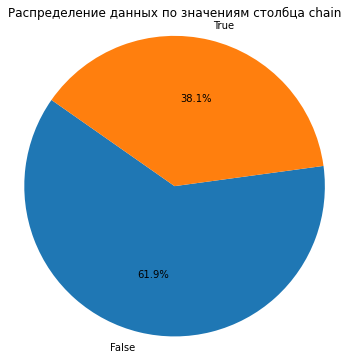

In [44]:
#Отобразим полученные данные на круговой диаграмме:
counts = df['chain'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=145)
plt.axis('equal')  # Чтобы диаграмма была круглой, а не эллиптической
plt.title('Распределение данных по значениям столбца chain')
plt.show()
 

Преобладание снесетевых заведений, однако и сетевых немало.

Распределение данных по значениям столбца chain в разрезе каждой категории:


<Figure size 720x432 with 0 Axes>

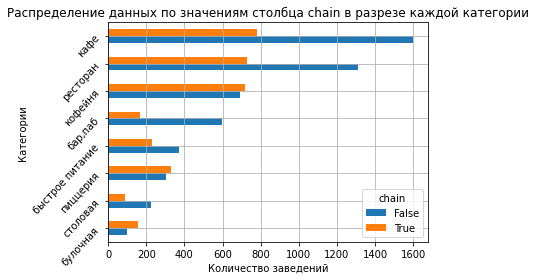

In [46]:
#Cоотношение сетевых и несетевых заведений в разрезе категорий заведения:
print('Распределение данных по значениям столбца chain в разрезе каждой категории:')
plt.figure(figsize=(10, 6))
result = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
result_sorted = result.sort_values(by=result.columns[0], ascending=True)
result_sorted.plot(kind='barh', rot=47)

 
# Настраиваем график
plt.title('Распределение данных по значениям столбца chain в разрезе каждой категории')
          
plt.ylabel('Категории') 
plt.xlabel('Количество заведений') 
plt.grid()
plt.tight_layout()
plt.show()

Несетевые заведения лидируют по категориям: кафе, ресторан, бар,паб ,быстрое питание, столовая. Преобладают сетевые заведения у категорий: кофейня, пиццерия, булочная.

Распределение данных по значениям столбца chain в разрезе каждой категории:


<Figure size 720x432 with 0 Axes>

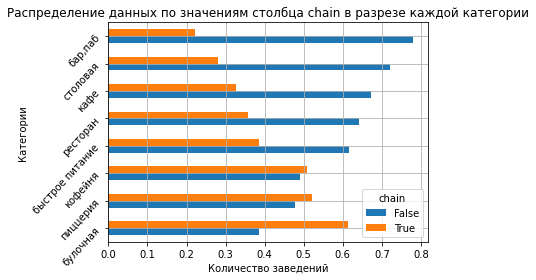

In [47]:
#Применим параметр normalize=True для лучшей визуализации соотношения сетевых и несетевых заведений в разрезе категорий:
#Cоотношение сетевых и несетевых заведений в разрезе категорий заведения:
print('Распределение данных по значениям столбца chain в разрезе каждой категории:')
plt.figure(figsize=(10, 6))
result = df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0)
result_sorted = result.sort_values(by=result.columns[0], ascending=True)
result_sorted.plot(kind='barh', rot=47)
plt.title('Распределение данных по значениям столбца chain в разрезе каждой категории')
          
plt.ylabel('Категории') 
plt.xlabel('Количество заведений') 
plt.grid()
plt.tight_layout()
plt.show()

Больше сетевых заведений в категориях:

- "кофейня", "пиццерия", "булочная".

Больше несетевых заведений в категориях: 
- "бар,паб", "столовая", "кафе", "ресторан", "быстрое питание"

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [49]:
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

- Всего посадочных мест: 4795
- Среднее количество: 108
- Медиана(50%): 75
- Минимальное: 0
- Максимальное: 1288
Среднее значение сильно смещено относительно медианы - это говорит нам о выбросах.

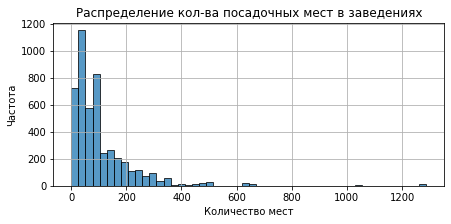

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist', 
                bins=50,
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение кол-ва посадочных мест в заведениях')
plt.xlabel('Количество мест')
plt.ylabel('Частота')

plt.grid()

plt.show()

Получилась гистограмма правоасимметричного распределения. Видим, что осеованая масса расположена в районе примерно 50-100 мест.

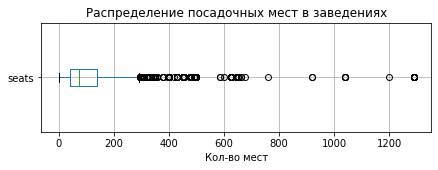

In [51]:
#Посмотрим на выбросы по "ящику с усами"
plt.figure(figsize=(7, 2))

df.boxplot(column='seats', vert=False)

plt.title('Распределение посадочных мест в заведениях')
plt.xlabel('Кол-во мест')

plt.show()

Наблюдаем выбросы - точки по правую сторону. Возможно причиа выбросов - места с большим количеством посадочных мест, например фудкорты.

In [53]:
#Проанализируем количество посадочных мест в зависимости от категории заведения:
df.groupby('category')['seats'].median().sort_values(ascending=False)

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

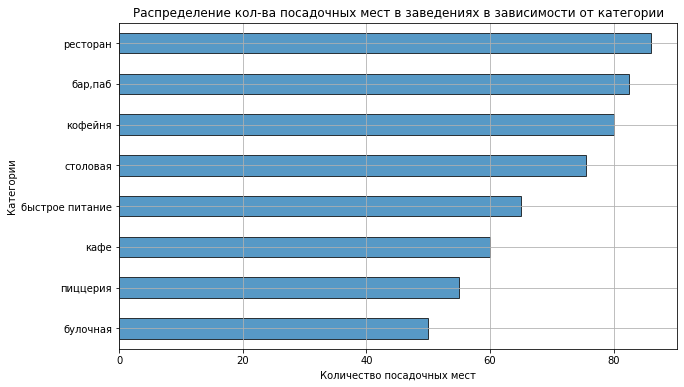

In [54]:
plt.figure(figsize=(10, 6))
df.groupby('category')['seats'].median().sort_values(ascending=True).plot(
                kind='barh', 
                alpha=0.75,
                edgecolor='black',
                rot=0 
)
plt.title('Распределение кол-ва посадочных мест в заведениях в зависимости от категории')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Категории')

plt.grid()

plt.show()

- Лидируют категории заведений "ресторан" и  "бар,паб" и "кофейня" (от 80 и более посадочных мест). 

- Категории с количеством посадочных мест до 80: 'быстрое питание', 'столовая'.

- Тройка категорий с наименьшим количеством посадочных мест: 'булочная', 'пиццерия', 'кафе' (до 60 посадочных мест).

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [55]:
df['rating'].describe()

count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

- Средняя оценка: 4.23,
- Минимальная: 1.0,
- Максимальная: 5.0,
- Медиана: 4.30
Можем полагать, что распределение нормальное так как медиана и среднее значения - близки.

In [58]:
#Проанализируем значение рейтинга в зависимости от категории заведения:
df.groupby('category')['rating'].mean().sort_values(ascending=False)

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290357
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.123886
быстрое питание    4.050249
Name: rating, dtype: float64

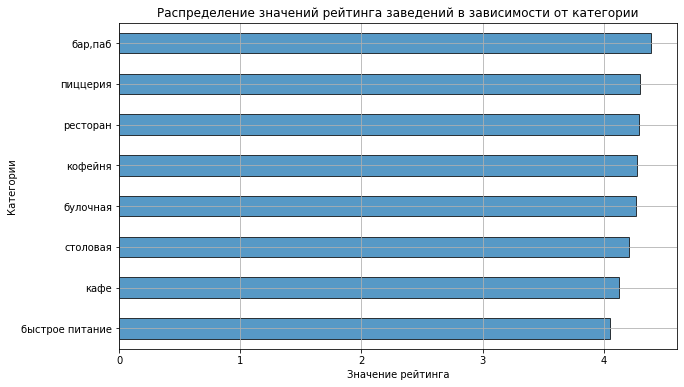

In [59]:
plt.figure(figsize=(10, 6))

df.groupby('category')['rating'].mean().sort_values(ascending=True).plot(
                kind='barh', 
                alpha=0.75,
                edgecolor='black',
                rot=0 
)
plt.title('Распределение значений рейтинга заведений в зависимости от категории')
plt.xlabel('Значение рейтинга')
plt.ylabel('Категории')

plt.grid()

plt.show()

Среди категорий наибольший средний балл - у заведений категории "бар,паб". Нельзя сказать, что рейтинг среди категорий сильно разнится: средние значение колеблются в районе 4х баллов.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [60]:
!pip install phik
import phik
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['seats', 'rating']


,rating
price,0.220295
district,0.200691
category,0.190003
is_24_7,0.168707
chain,0.108092
seats,0.000000


Наибольшая корреляция рейтинга наблюдается с ценовой категорией и административным районом, где расположено заведение. Заметно, что количество мест вообще не влияет на рейтинг заведения.

Text(0.5, 33.0, 'Рейтинг')

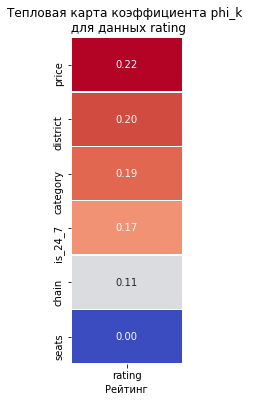

In [61]:
#Применим тепловую карту для наглядности: 
plt.figure(figsize=(2, 6))
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5, 
            cbar=False 
           )

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')

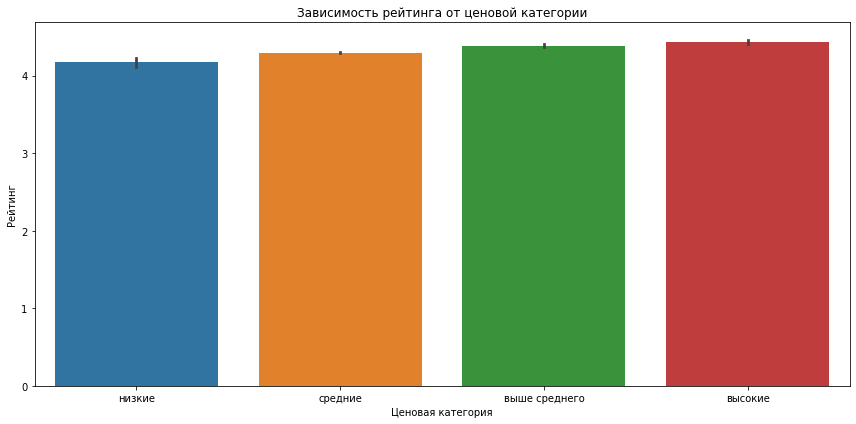

In [62]:
#Рассмотрим взаимосвязь ценовой категории с рейтингом заведения:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='price', y='rating', order=['низкие','средние','выше среднего','высокие'])
plt.title('Зависимость рейтинга от ценовой категории')
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')
plt.tight_layout()
plt.show()

Тут мы видим прямую зависимость: чем ниже категория цены - тем ниже рейтинг, чем выше категория - тем выше рейтинг.

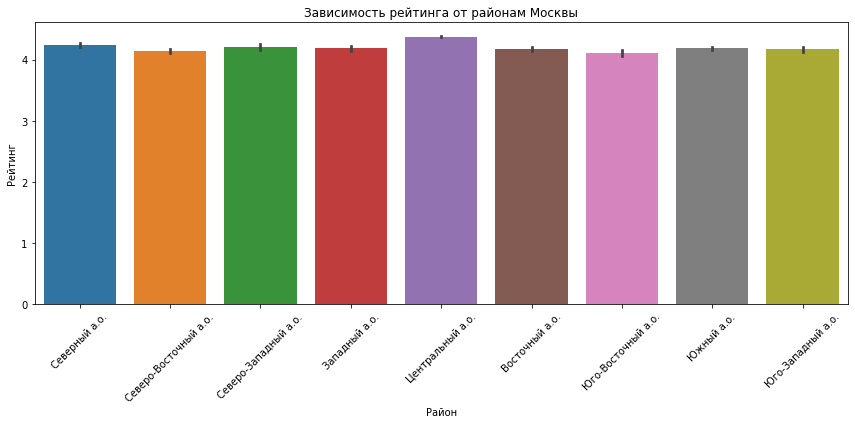

In [63]:
#Рассмотрим взаимосвязь административного района с рейтингом заведения подробнее:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='district', y='rating')
plt.xticks(rotation=45)
plt.title('Зависимость рейтинга от районам Москвы')
plt.xlabel('Район')
plt.ylabel('Рейтинг')
plt.tight_layout()
plt.show()


              

Влияние административного района влияет на рейтинг, но незначительно - значение рейтинга остается в пределах 4х баллов.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [66]:
df_chain = df.loc[df['chain']==1]
topp_15 = df_chain['name'].value_counts().head(15)
print(topp_15)


Шоколадница                            120
Домино'с Пицца                          76
Додо Пицца                              74
One Price Coffee                        71
Яндекс Лавка                            69
Cofix                                   65
Prime                                   50
Хинкальная                              44
КОФЕПОРТ                                42
Кулинарная лавка братьев Караваевых     39
Теремок                                 38
Чайхана                                 37
CofeFest                                32
Буханка                                 32
Му-Му                                   27
Name: name, dtype: int64


Возглавляют рейтинг - заведения сети "Шоколадница".

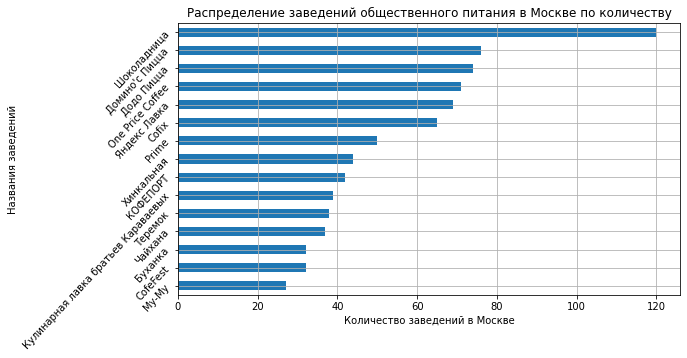

In [67]:
plt.figure(figsize=(9, 5))
topp_15.sort_values(ascending=True).plot(kind='barh', 
            rot=47, 
            legend=False, 
            title=f'Распределение заведений общественного питания в Москве по количеству'
)
plt.xlabel('Количество заведений в Москве')
plt.ylabel('Названия заведений')

plt.grid()
plt.show()

In [73]:
top_15_names = df['name'].value_counts().head(15).index
top_15_df = df[df['name'].isin(top_15_names)]

top_15_summary = top_15_df.groupby('name').agg({
    'rating': 'mean',
    'name': 'count',
    'category': 'first'}).rename(columns={'name': 'count'})

top_15_summary = top_15_summary.sort_values(by='count', ascending=False)

print(top_15_summary)


                                       rating  count         category
name                                                                 
Кафе                                 3.880952    189             кафе
Шоколадница                          4.177500    120          кофейня
Домино'с Пицца                       4.169737     76         пиццерия
Додо Пицца                           4.286486     74         пиццерия
One Price Coffee                     4.064789     71          кофейня
Яндекс Лавка                         3.872464     69         ресторан
Cofix                                4.075385     65          кофейня
Prime                                4.116000     50         ресторан
Хинкальная                           4.322727     44  быстрое питание
Шаурма                               3.909302     43  быстрое питание
КОФЕПОРТ                             4.147619     42          кофейня
Кулинарная лавка братьев Караваевых  4.394872     39             кафе
Теремок             

- Больше всего заведений сети под названием "Шоколадница".

- Топ 5 заведений по рейтингу (убывание): "Кулинарная лавка братьев Караваевых", "Хинкальная", "Ресторан", "Додо Пицца", "Шоколадница".

- Наиболее популярные категории заведений: "ресторан" и "кофейня". Наименее популярные: "быстрое питание" и "пиццерия".



---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [71]:
avg_bill_by_district = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)
print(avg_bill_by_district)

district
Центральный а.о.         1191.057547
Западный а.о.            1053.225490
Северный а.о.             927.959627
Южный а.о.                834.398089
Северо-Западный а.о.      822.222930
Восточный а.о.            820.626923
Юго-Западный а.о.         792.561702
Северо-Восточный а.о.     716.611296
Юго-Восточный а.о.        654.097938
Name: middle_avg_bill, dtype: float64


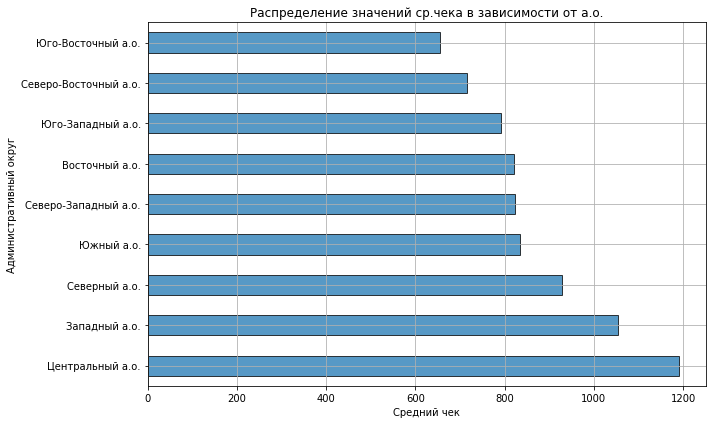

In [72]:
plt.figure(figsize=(10, 6))
avg_bill_by_district.plot(
                kind='barh', 
                alpha=0.75,
                edgecolor='black',
                rot=0 
)
plt.title('Распределение значений ср.чека в зависимости от а.о.')
plt.xlabel('Средний чек')
plt.ylabel('Административный округ')

plt.grid()
plt.tight_layout()
plt.show()

Можно сделать вывод: чем ближе к центральному административному округу - тем выше значение среднего чека в заведении.

---


---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

- По полулярности - лидирует категория "кафе", на втором месте "ресторан", на третьем - "кофейня".

- Больше всего заведений в Центральный административном округе, меньше всего заведений - в Северо-Западном административном округе. Остальные - занимают промежуточное значение.

- Больше всего посадочнеых мест: "ресторан" и  "бар,паб" и "кофейня" (от 80 и более). 

- Категории с количеством посадочных мест 60-80: 'быстрое питание', 'столовая'.

- Тройка категорий с наименьшим количеством посадочных мест: 'булочная', 'пиццерия', 'кафе' (до 60).

- Больше всего на рейтинг заведения влияет его ценовая категория, в меньшей мере влияет район. 
- Влияние категории на значение рейтинга невелико.
- Количество посадочных мест не влияет на рейтинг совсем.

- Наиболее популярные категории заведений: "ресторан" и "кофейня". Наименее популярные: "быстрое питание".


## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.
---
1. Была проделана работа: подготовлен единый датафрейм с информацией о заведениях общественного питания г.Москвы, среднем чеке в заведениях общественного питания. Проведен анализ данных на дубликаты, пропуски, просмотрены уникальные значения на предмет некорректных данных. Добавлены несколько стобцов для удобства дальнейшего анализа данных. 
Проведен исследовательский анализ данных, с ответами на вопросы:

2. Какие категории заведений представлены в данных? 
- Категории заведений и их количество:
  - кафе               2378
  - ресторан           2043
  - кофейня            1413
  - бар,паб             765
  - пиццерия            633
  - быстрое питание     603
  - столовая            315
  - булочная            256
  
Какие административные районы Москвы присутствуют в данных? 
Распределение заведений каждой категории в Центральном административном округе Москвы.
- Администратвные районы Москвы с количеством представленные в данных: 
  - Центральный а.о.         2242
  - Северный а.о.             900
  - Южный а.о.                892
  - Северо-Восточный а.о.     891
  - Западный а.о.             851
  - Восточный а.о.            798
  - Юго-Восточный а.о.        714
  - Юго-Западный а.о.         709
  - Северо-Западный а.о.      409

- Категории заведений в Центральном административном округе, количество:
  - ресторан           670
  - кафе               464
  - кофейня            428
  - бар,паб            364
  - пиццерия           113
  - быстрое питание     87
  - столовая            66
  - булочная            50

Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми?
- Больше сетевых заведений в категориях:
  - "кофейня", "пиццерия", "булочная".
- Больше несетевых заведений в категориях: 
  - "бар,паб", "столовая", "кафе", "ресторан", "быстрое питание"

- Наиболее типичное среднее количество посадочных мест для каждой категории:
  - ресторан           86.0
  - бар,паб            82.5
  - кофейня            80.0
  - столовая           75.5
  - быстрое питание    65.0
  - кафе               60.0
  - пиццерия           55.0
  - булочная           50.0
  
Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. 
- Возможно причиа выбросов - места с большим количеством посадочных мест, например фудкорты.
- Лидируют категории заведений "ресторан" и  "бар,паб" (от 80 и более посадочных мест). 
- Категории с количеством посадочных мест до 80: 'быстрое питание', 'столовая'.
- Тройка категорий с наименьшим количеством посадочных мест: 'булочная', 'пиццерия', 'кафе' (до 60 посадочных мест).

Сильно ли различаются усреднённые рейтинги для разных типов общепита?
- Для разных типов общепита усредненные рейтинги разнятся несильно, от 4.05 до 4.39.

С какими данными показывают самую сильную корреляцию рейтинги заведений?
- Самая сильная корреляция  рейтинга наблюдается с показателем категории цен.

К какой категории заведений относятся топ-15 заведений москвы? 
- Наиболее популярные категории среди топ-15 заведений Москвы: "ресторан" и "кофейня".

 Как удалённость от центра влияет на цены в заведениях?
- Чем ближе к центральному административному округу - тем выше значение среднего чека в заведении. 

3. Рекомендации: 
Стоит помнить, что анализ проводился на данных летнего сезона, нужно помнить о влиянии сезонности на все характеристики заведений общепита. 
Будущее заведение зависит от желаний инвесторов фонда Shut Up and Take My Money, от уровня финансов, которые планируют вложить в проект. 
Возможно стоит уделить внимание наименее популярным категориям - можно придумать новую концепцию, которая будет иметь больше шансов на успех так как конкуренция среди непопулярных категорий ниже, чем у популярных. Можно и довериться проверенным и поппулярным категориям, если вы не готовы к экспериментам. Конечно, если для вас важен рейтинг - то тут категория заведения не имеет веса. 

